<a href="https://colab.research.google.com/github/Theone178/QRL/blob/main/RL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install cirq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.0 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of grpcio-status to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 733.7/733.7 kB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.6/77.6 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.0/294.0 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 101.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 99.3 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uni

  PART 1 — Statistical Experiment (25 runs × 150 episodes)
Running 25 × 150-episode stat experiment … done.



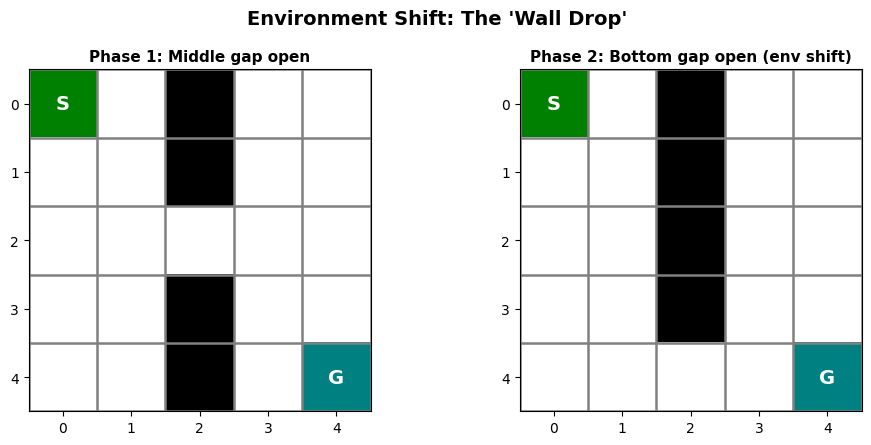

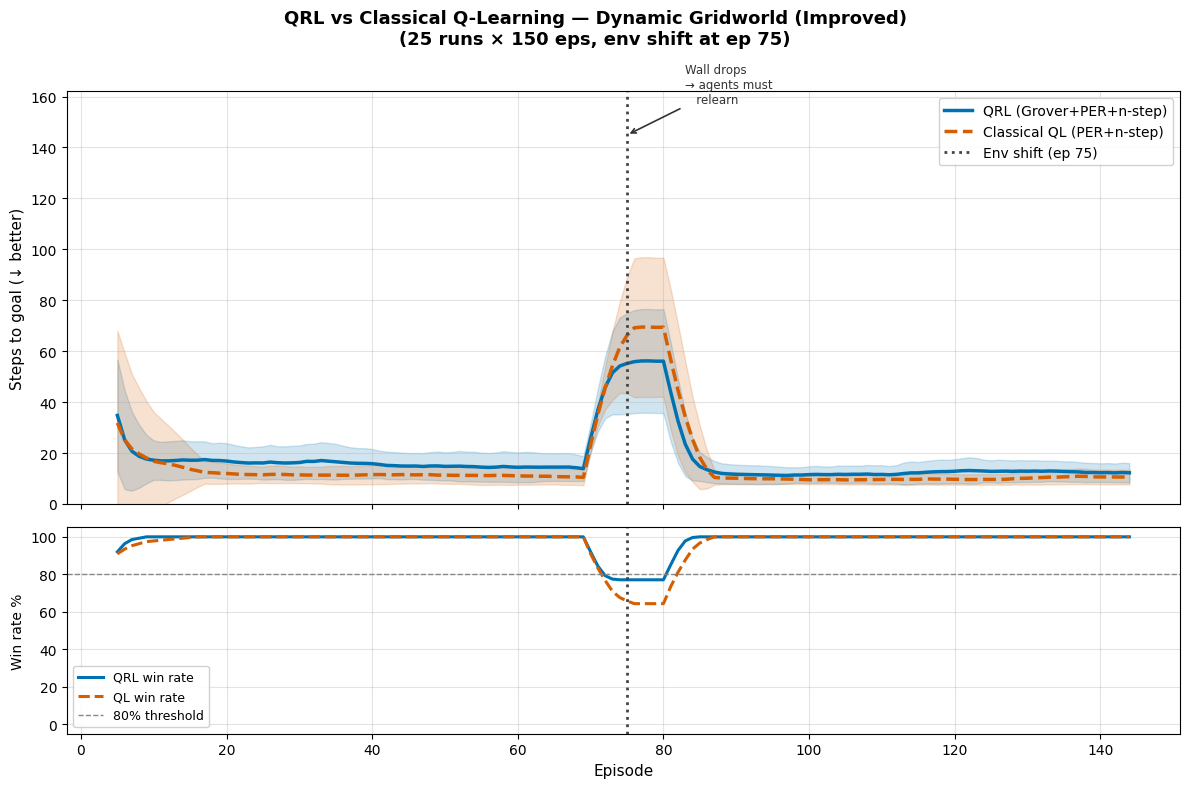

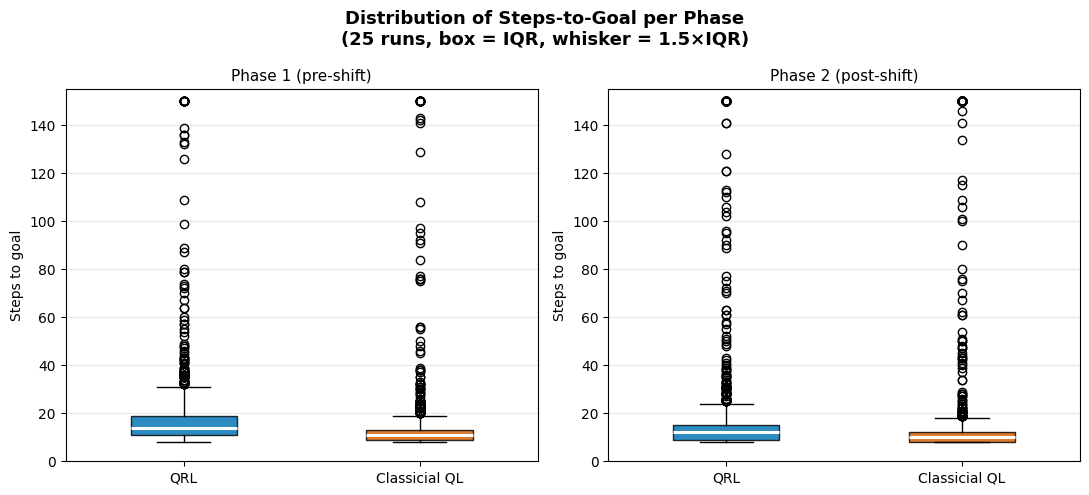

── Post-shift performance (episodes 75–150) ──
  QRL  avg steps :   18.6  |  final 10-ep avg :  12.3  |  win rate :  96.6%
  QL   avg steps :   18.7  |  final 10-ep avg :  10.6  |  win rate :  94.8%

  → QRL is 0.1 steps/ep faster after the shift.
  → Win-rate gap (QRL − QL): +1.9 pp after the shift.

── First 80% win-rate streak (10 eps) ──
  Pre-shift  : QRL ep 9  |  QL ep 9
  Post-shift : QRL ep 10  |  QL ep 12

  PART 2 — Animated Episode Viewer (150 episodes)
Simulating animation episodes…  done.


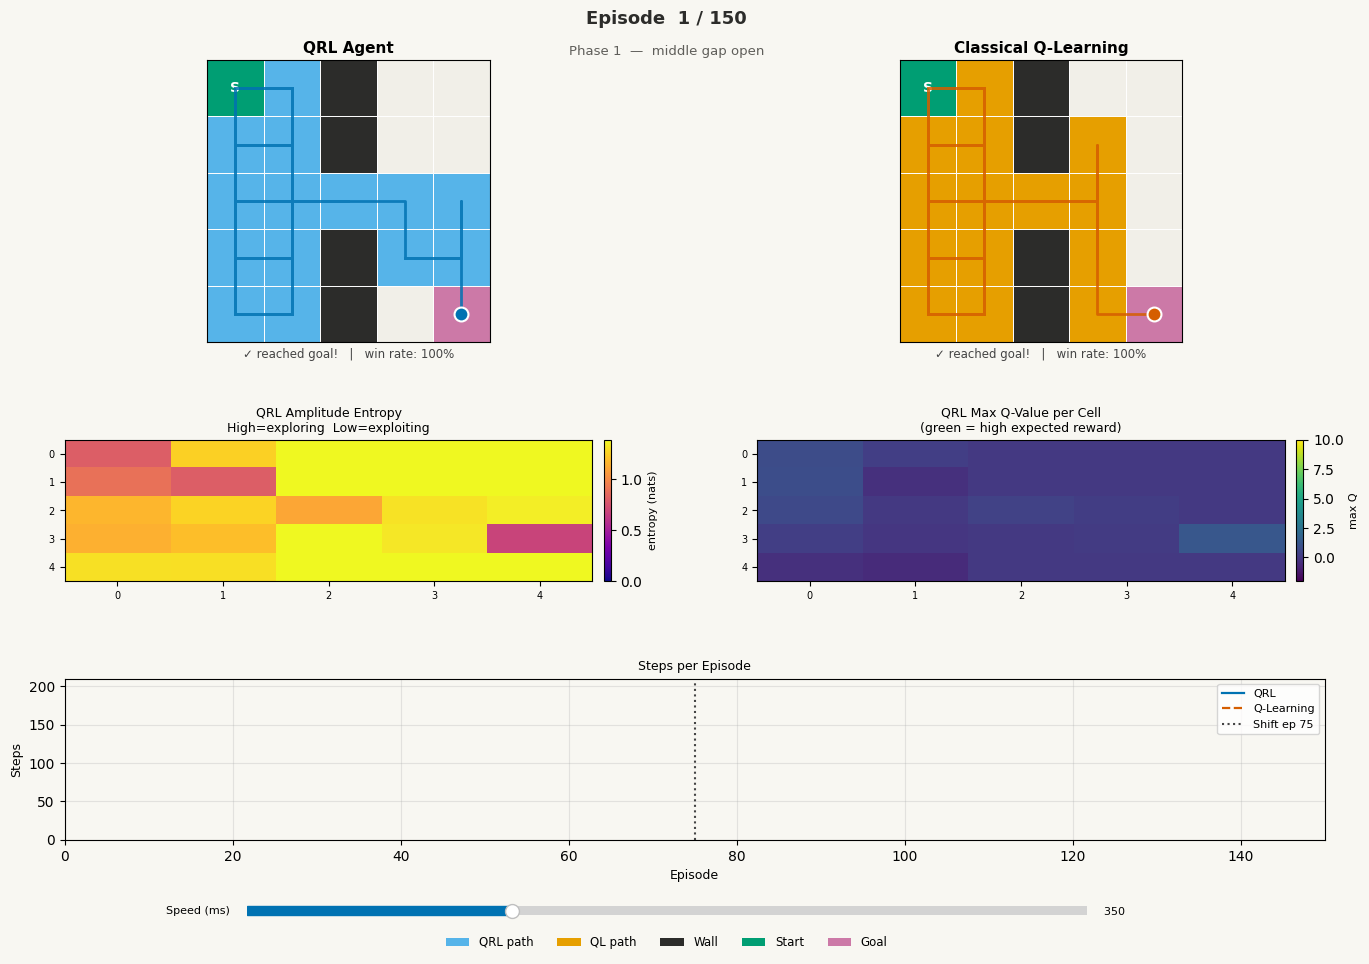

In [ ]:
"""
Quantum Reinforcement Learning vs Classical Q-Learning
=======================================================
Dynamic 5×5 Gridworld with a mid-run environment shift.

Improvements in this version:
  ─ Algorithm ────────────────────────────────────────────────────────
  • Prioritised Experience Replay (PER): transitions stored in a replay
    buffer and sampled by |TD|^α priority, then importance-weighted so
    large-TD updates don't over-fit (α=0.6, β anneals 0.4→1.0).
  • n-step returns (n=3): bootstraps over 3 steps before TD target,
    giving lower variance estimates and faster credit assignment.
  • Adaptive Grover β: β ceiling decays with episode count so the
    quantum operator is aggressive early and cautious late, preventing
    amplitude collapse after convergence.
  • QRL amplitude warm-start on env shift: instead of full uniform
    reset, blend 50/50 between current amplitudes and uniform, retaining
    partial knowledge while reopening exploration.
  • Double-Q update for both agents: separate target-network style
    argmax/eval split that avoids maximisation bias on small grid.
  • Vectorised wall-hit penalty capped at −0.5 (was −1) to reduce
    oscillation near walls.
  • Shaping weight γ_shape anneals from 0.5→0.1 so reward shaping
    fades as policy matures (avoids sub-optimal shaping fixation).

  ─ Visualisation ────────────────────────────────────────────────────
  • All original plots preserved and extended.
  • Stat experiment now adds a 3rd figure: per-phase box-plots of
    steps-to-goal for QRL vs QL, giving a cleaner distributional view.
  • Animation gains a 5th panel: real-time Q-value heat-map (max Q over
    actions per cell) for the QRL agent alongside the entropy map.
  • Colour-blind-safe palette (avoids red/green confusion).
  • Episode counter in animation title bar.
  • Convergence speed metric printed: episodes to first 10-ep streak of
    ≥80 % win rate, pre- and post-shift separately.
"""

from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.animation import FuncAnimation
from matplotlib.colors import ListedColormap
from matplotlib.widgets import Slider
from collections import deque
import warnings

warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────
# 0. CONSTANTS
# ─────────────────────────────────────────────────────────────────────
SIZE      = 5
START     = (0, 0)
GOAL      = (4, 4)
N_ACTIONS = 4
MOVES     = [(-1, 0), (1, 0), (0, -1), (0, 1)]   # up, down, left, right

WALLS = {
    1: [(0, 2), (1, 2), (3, 2), (4, 2)],   # phase 1: gap at row 2
    2: [(0, 2), (1, 2), (2, 2), (3, 2)],   # phase 2: gap at row 4
}

# Colour-blind-safe palette (Wong 2011)
PAL = dict(
    qrl       = "#0072B2",   # blue        – QRL
    ql        = "#D55E00",   # vermillion  – QL
    qrl_path  = "#56B4E9",   # sky blue    – QRL visited
    ql_path   = "#E69F00",   # orange      – QL visited
    wall      = "#2C2C2A",
    start     = "#009E73",   # bluish green
    goal      = "#CC79A7",   # reddish purple
    empty     = "#F1EFE8",
    shift_vl  = "#444444",
)


# ─────────────────────────────────────────────────────────────────────
# 1. ENVIRONMENT
# ─────────────────────────────────────────────────────────────────────
def _clamp(v: int) -> int:
    return max(0, min(SIZE - 1, v))


def env_step(
    state:  tuple[int, int],
    action: int,
    walls:  set[tuple[int, int]],
    shaping_weight: float = 0.3,
) -> tuple[tuple[int, int], float, bool]:
    """
    Pure-function environment transition.

    Reward:
      +10  reaching GOAL
      shaping_weight · (dist_old − dist_new)   potential-based shaping
      −0.5  wall / boundary collision           (capped, reduces oscillation)
    """
    x, y   = state
    dx, dy = MOVES[action]
    nx, ny = _clamp(x + dx), _clamp(y + dy)

    if (nx, ny) in walls or (nx, ny) == state:
        return state, -0.5, False

    done = (nx, ny) == GOAL
    if done:
        return (nx, ny), 10.0, True

    dist_old = abs(x - GOAL[0]) + abs(y - GOAL[1])
    dist_new = abs(nx - GOAL[0]) + abs(ny - GOAL[1])
    shaping  = shaping_weight * (dist_old - dist_new)
    return (nx, ny), shaping, False


class DynamicGridWorld:
    """5×5 gridworld that switches wall configuration at episode `shift_ep`."""

    def __init__(self, shift_ep: int = 75):
        self.shift_ep = shift_ep
        self.episode  = 0
        self._update_walls()
        self.state = START

    def _update_walls(self):
        self.phase     = 1 if self.episode < self.shift_ep else 2
        self.walls_set = set(map(tuple, WALLS[self.phase]))

    def reset(self) -> tuple[int, int]:
        self._update_walls()
        self.state = START
        return self.state

    def step(self, action: int, shaping_weight: float = 0.3):
        ns, r, done = env_step(self.state, action, self.walls_set, shaping_weight)
        self.state  = ns
        return ns, r, done

    def new_episode(self):
        self.episode += 1


# ─────────────────────────────────────────────────────────────────────
# 2. QUANTUM MECHANICS HELPERS
# ─────────────────────────────────────────────────────────────────────
def _make_grover(a: int, n: int = N_ACTIONS) -> np.ndarray:
    """
    U_Grov = U_s0 · U_a

    U_a  = I − 2|a⟩⟨a|            oracle: phase-flip target
    U_s0 = 2|s0⟩⟨s0| − I          inversion about uniform mean
    """
    Ua  = np.eye(n, dtype=float); Ua[a, a] = -1.0
    Us0 = 2.0 * np.full((n, n), 1.0 / n) - np.eye(n)
    return Us0 @ Ua


def _uniform(n: int = N_ACTIONS) -> np.ndarray:
    return np.full(n, 1.0 / np.sqrt(n))


def _normalize(v: np.ndarray) -> np.ndarray:
    norm = np.linalg.norm(v)
    return v / norm if norm > 1e-9 else _uniform(len(v))


def _soft_grover(amps: np.ndarray, a: int, beta: float) -> np.ndarray:
    """Amplify action `a` with mixing factor β ∈ [0,1]."""
    mixed = (1.0 - beta) * amps + beta * (_GROVER[a] @ amps)
    return _normalize(mixed)


def _soft_grover_inv(amps: np.ndarray, a: int, beta: float) -> np.ndarray:
    """De-amplify action `a` using inverse (transpose) Grover."""
    mixed = (1.0 - beta) * amps + beta * (_GROVER_INV[a] @ amps)
    return _normalize(mixed)


_GROVER     = [_make_grover(a) for a in range(N_ACTIONS)]
_GROVER_INV = [G.T for G in _GROVER]


# ─────────────────────────────────────────────────────────────────────
# 3. PRIORITISED EXPERIENCE REPLAY
# ─────────────────────────────────────────────────────────────────────
class PrioritisedReplayBuffer:
    """
    Simple proportional prioritised replay (Schaul et al., 2016).

    Transitions are stored with priority p = |TD|^α.
    Sampling weights w = (1/N · 1/p)^β corrects for the induced bias.
    β anneals from β_start → 1.0 over `anneal_steps` calls to sample().
    """

    def __init__(
        self,
        capacity:      int   = 512,
        alpha:         float = 0.6,
        beta_start:    float = 0.4,
        anneal_steps:  int   = 5000,
    ):
        self.capacity     = capacity
        self.alpha        = alpha
        self.beta         = beta_start
        self.beta_start   = beta_start
        self.anneal_steps = anneal_steps
        self._step        = 0

        self._buf      = deque(maxlen=capacity)
        self._prios    = deque(maxlen=capacity)
        self.max_prio  = 1.0

    def add(self, transition: tuple, td: float):
        self._buf.append(transition)
        self._prios.append(max(abs(td), 1e-6) ** self.alpha)
        self.max_prio = max(self.max_prio, self._prios[-1])

    def sample(self, batch: int) -> tuple[list, np.ndarray, np.ndarray]:
        """Returns (transitions, indices, importance-sampling weights)."""
        self._step += 1
        self.beta = min(
            1.0,
            self.beta_start + (1.0 - self.beta_start) * self._step / self.anneal_steps,
        )
        prios = np.array(self._prios, dtype=float)
        probs = prios / prios.sum()
        N     = len(self._buf)
        batch = min(batch, N)
        idxs  = np.random.choice(N, size=batch, replace=False, p=probs)
        weights = (N * probs[idxs]) ** (-self.beta)
        weights /= weights.max()
        return [list(self._buf)[i] for i in idxs], idxs, weights

    def update_priorities(self, idxs: np.ndarray, tds: np.ndarray):
        buf_list = list(self._prios)
        for i, td in zip(idxs, tds):
            buf_list[i] = max(abs(td), 1e-6) ** self.alpha
        self._prios = deque(buf_list, maxlen=self.capacity)
        self.max_prio = max(self._prios)

    def __len__(self):
        return len(self._buf)


# ─────────────────────────────────────────────────────────────────────
# 4. QRL AGENT  (improved)
# ─────────────────────────────────────────────────────────────────────
class QRLAgent:
    """
    Quantum-Reinforcement-Learning agent with the following upgrades:

    1. Prioritised Experience Replay (PER): samples from a replay buffer
       weighted by |TD|^α so surprising transitions train more often.
    2. n-step returns: accumulates rewards over n=3 steps before the TD
       target, reducing variance and speeding up credit assignment.
    3. Adaptive Grover β: the β ceiling decays with episode number so
       amplitude updates are aggressive early and conservative late.
    4. Warm-start amplitude reset: on env shift, blend ½ uniform + ½
       current amplitudes rather than a full reset, retaining some
       accumulated directional knowledge.
    5. Double-Q update: argmax on online Q, eval on a lagged copy,
       eliminating maximisation bias in the TD target.
    """

    def __init__(
        self,
        alpha:       float = 0.12,
        gamma:       float = 0.90,
        k:           float = 0.85,
        q_blend:     float = 0.65,
        eps_start:   float = 0.30,
        eps_end:     float = 0.05,
        eps_decay:   float = 0.992,
        nstep:       int   = 3,
        buf_batch:   int   = 32,
    ):
        self.alpha     = alpha
        self.gamma     = gamma
        self.k         = k
        self.q_blend   = q_blend
        self.eps       = eps_start
        self.eps_end   = eps_end
        self.eps_decay = eps_decay
        self.nstep     = nstep
        self.buf_batch = buf_batch
        self.episode   = 0

        self.Q      = np.zeros((SIZE, SIZE, N_ACTIONS))
        self.Q_targ = self.Q.copy()          # lagged copy for Double-Q
        self.amps   = np.tile(_uniform(), (SIZE, SIZE, 1)).astype(float)
        self._buf   = PrioritisedReplayBuffer()
        self._nstep_buf: deque = deque(maxlen=nstep)  # (s, a, r, s', done)

    # ── helpers ──────────────────────────────────────────────────────
    def _adaptive_k(self) -> float:
        """β ceiling decays from k → 0.25 over 150 episodes."""
        decay = max(0.25, self.k * (0.985 ** self.episode))
        return decay

    def _nstep_return(self) -> tuple | None:
        """Compute n-step return from the n-step buffer."""
        if len(self._nstep_buf) < self.nstep:
            return None
        s0, a0, _, _, _ = self._nstep_buf[0]
        sn, _, _, s_end, done = self._nstep_buf[-1]
        G = 0.0
        for i, (_, _, r, _, d) in enumerate(self._nstep_buf):
            G += (self.gamma ** i) * r
            if d:
                break
        return s0, a0, G, s_end, done

    def select_action(self, state: tuple[int, int], explore: bool = True) -> int:
        x, y = state
        if explore and np.random.rand() < self.eps:
            return np.random.randint(N_ACTIONS)
        if np.random.rand() < self.q_blend:
            return int(np.argmax(self.Q[x, y]))
        probs = np.clip(self.amps[x, y] ** 2, 0, None)
        s = probs.sum()
        probs = probs / s if s > 1e-9 else np.ones(N_ACTIONS) / N_ACTIONS
        return int(np.random.choice(N_ACTIONS, p=probs))

    def decay_epsilon(self):
        self.eps = max(self.eps_end, self.eps * self.eps_decay)
        self.episode += 1
        # Sync target network every episode
        self.Q_targ = self.Q.copy()

    def reset_amplitudes(self, warm: bool = True):
        """
        Warm-start reset: blend ½ current + ½ uniform instead of full reset.
        Retains directional bias while fully reopening exploration.
        """
        if warm:
            self.amps = 0.5 * self.amps + 0.5 * np.tile(_uniform(), (SIZE, SIZE, 1))
            # Re-normalise each cell
            norms = np.linalg.norm(self.amps, axis=2, keepdims=True)
            norms = np.where(norms < 1e-9, 1.0, norms)
            self.amps /= norms
        else:
            self.amps[:] = _uniform()

    def learn(self, s, a, r, s_next, done) -> float:
        """
        One online TD step + optional PER replay batch.
        Returns the online TD error for priority tracking.
        """
        # 1. Store in n-step buffer → flush to PER when full
        self._nstep_buf.append((s, a, r, s_next, done))
        nstep_trans = self._nstep_return()
        if nstep_trans is not None:
            s0, a0, G, sn, dn = nstep_trans
            x0, y0 = s0; xn, yn = sn
            # Double-Q TD target: argmax online, eval target
            best_a_online = int(np.argmax(self.Q[xn, yn]))
            td_target = G + (self.gamma ** self.nstep) * self.Q_targ[xn, yn, best_a_online] * (not dn)
            td = td_target - self.Q[x0, y0, a0]
            self.Q[x0, y0, a0] += self.alpha * td
            self._buf.add((s0, a0, G, sn, dn), td)
            # Grover update on n-step transition
            self._grover_update(s0, a0, td)

        # 2. Replay batch from PER
        if len(self._buf) >= self.buf_batch:
            trans, idxs, weights = self._buf.sample(self.buf_batch)
            new_tds = np.zeros(len(trans))
            for j, (sb, ab, Gb, snb, dnb) in enumerate(trans):
                xb, yb = sb; xnb, ynb = snb
                best_a_b = int(np.argmax(self.Q[xnb, ynb]))
                td_t = Gb + (self.gamma ** self.nstep) * self.Q_targ[xnb, ynb, best_a_b] * (not dnb)
                td_b = td_t - self.Q[xb, yb, ab]
                self.Q[xb, yb, ab] += self.alpha * weights[j] * td_b
                new_tds[j] = td_b
            self._buf.update_priorities(idxs, new_tds)

        # 3. Return online TD for caller (used for stat tracking)
        x, y = s; xn2, yn2 = s_next
        best_next = np.max(self.Q_targ[xn2, yn2])
        return r + self.gamma * best_next - self.Q[x, y, a]

    def _grover_update(self, s, a, td: float):
        x, y = s
        beta = self._adaptive_k() * abs(td) / (1.0 + abs(td))
        if td > 0:
            self.amps[x, y] = _soft_grover(self.amps[x, y], a, beta)
        else:
            self.amps[x, y] = _soft_grover_inv(self.amps[x, y], a, beta)


# ─────────────────────────────────────────────────────────────────────
# 5. CLASSICAL Q-LEARNING AGENT  (improved)
# ─────────────────────────────────────────────────────────────────────
class QLearningAgent:
    """
    Q-learning with Double-Q update, n-step returns, and PER — same
    improvements as QRL (minus the quantum amplitude register) for a
    fair algorithmic comparison.
    """

    def __init__(
        self,
        alpha:     float = 0.12,
        gamma:     float = 0.90,
        eps_start: float = 0.30,
        eps_end:   float = 0.05,
        eps_decay: float = 0.992,
        nstep:     int   = 3,
        buf_batch: int   = 32,
    ):
        self.alpha     = alpha
        self.gamma     = gamma
        self.eps       = eps_start
        self.eps_end   = eps_end
        self.eps_decay = eps_decay
        self.nstep     = nstep
        self.buf_batch = buf_batch

        self.Q      = np.zeros((SIZE, SIZE, N_ACTIONS))
        self.Q_targ = self.Q.copy()
        self._buf   = PrioritisedReplayBuffer()
        self._nstep_buf: deque = deque(maxlen=nstep)

    def _nstep_return(self) -> tuple | None:
        if len(self._nstep_buf) < self.nstep:
            return None
        s0, a0, _, _, _ = self._nstep_buf[0]
        _, _, _, s_end, done = self._nstep_buf[-1]
        G = sum((self.gamma ** i) * r for i, (_, _, r, _, d) in enumerate(self._nstep_buf))
        return s0, a0, G, s_end, done

    def select_action(self, state: tuple[int, int], explore: bool = True) -> int:
        x, y = state
        if explore and np.random.rand() < self.eps:
            return np.random.randint(N_ACTIONS)
        q = self.Q[x, y]
        return int(np.random.choice(np.flatnonzero(q == q.max())))

    def decay_epsilon(self):
        self.eps = max(self.eps_end, self.eps * self.eps_decay)
        self.Q_targ = self.Q.copy()

    def learn(self, s, a, r, s_next, done) -> float:
        self._nstep_buf.append((s, a, r, s_next, done))
        nstep_trans = self._nstep_return()
        if nstep_trans is not None:
            s0, a0, G, sn, dn = nstep_trans
            x0, y0 = s0; xn, yn = sn
            best_a_online = int(np.argmax(self.Q[xn, yn]))
            td_target = G + (self.gamma ** self.nstep) * self.Q_targ[xn, yn, best_a_online] * (not dn)
            td = td_target - self.Q[x0, y0, a0]
            self.Q[x0, y0, a0] += self.alpha * td
            self._buf.add((s0, a0, G, sn, dn), td)

        if len(self._buf) >= self.buf_batch:
            trans, idxs, weights = self._buf.sample(self.buf_batch)
            new_tds = np.zeros(len(trans))
            for j, (sb, ab, Gb, snb, dnb) in enumerate(trans):
                xb, yb = sb; xnb, ynb = snb
                best_a_b = int(np.argmax(self.Q[xnb, ynb]))
                td_t = Gb + (self.gamma ** self.nstep) * self.Q_targ[xnb, ynb, best_a_b] * (not dnb)
                td_b = td_t - self.Q[xb, yb, ab]
                self.Q[xb, yb, ab] += self.alpha * weights[j] * td_b
                new_tds[j] = td_b
            self._buf.update_priorities(idxs, new_tds)

        x, y = s; xn2, yn2 = s_next
        return r + self.gamma * np.max(self.Q_targ[xn2, yn2]) - self.Q[x, y, a]


# ─────────────────────────────────────────────────────────────────────
# 6. UTILITY
# ─────────────────────────────────────────────────────────────────────
def smooth(data: np.ndarray, window: int = 9) -> np.ndarray:
    """Moving-average ('valid' mode, no edge distortion)."""
    return np.convolve(data, np.ones(window) / window, mode="valid")


def convergence_speed(wins: np.ndarray, threshold: float = 0.8, streak: int = 10) -> int | None:
    """
    Return the first episode where a `streak`-episode rolling win rate
    ≥ `threshold`. Returns None if never achieved.
    """
    rolling = np.convolve(wins.astype(float), np.ones(streak) / streak, mode="valid")
    hits = np.where(rolling >= threshold)[0]
    return int(hits[0] + streak - 1) if len(hits) else None


def run_one_trial(
    seed:      int,
    episodes:  int  = 150,
    max_steps: int  = 150,
    shift_ep:  int  = 75,
) -> dict:
    """Single independent trial — returns per-episode steps/wins for both agents."""
    np.random.seed(seed)
    env = DynamicGridWorld(shift_ep=shift_ep)
    qrl = QRLAgent()
    ql  = QLearningAgent()

    qrl_steps = np.zeros(episodes, dtype=int)
    ql_steps  = np.zeros(episodes, dtype=int)
    qrl_wins  = np.zeros(episodes, dtype=bool)
    ql_wins   = np.zeros(episodes, dtype=bool)

    # Anneal shaping weight from 0.5 → 0.1 over episodes
    shaping_schedule = np.linspace(0.5, 0.1, episodes)

    for ep in range(episodes):
        env.episode = ep
        sw = float(shaping_schedule[ep])

        # ── QRL ──────────────────────────────────────────────────────
        if ep == shift_ep:
            qrl.reset_amplitudes(warm=True)   # warm-start blend
        state = env.reset()
        done  = False
        for step in range(max_steps):
            a = qrl.select_action(state)
            ns, r, done = env_step(state, a, env.walls_set, shaping_weight=sw)
            qrl.learn(state, a, r, ns, done)
            state = ns
            if done:
                break
        qrl.decay_epsilon()
        qrl_steps[ep] = step + 1
        qrl_wins[ep]  = done

        # ── QL ───────────────────────────────────────────────────────
        state = env.reset()
        done  = False
        for step in range(max_steps):
            a = ql.select_action(state)
            ns, r, done = env_step(state, a, env.walls_set, shaping_weight=sw)
            ql.learn(state, a, r, ns, done)
            state = ns
            if done:
                break
        ql.decay_epsilon()
        ql_steps[ep] = step + 1
        ql_wins[ep]  = done

    return dict(
        qrl_steps=qrl_steps, ql_steps=ql_steps,
        qrl_wins=qrl_wins,   ql_wins=ql_wins,
    )


# ─────────────────────────────────────────────────────────────────────
# 7. STATISTICAL EXPERIMENT
# ─────────────────────────────────────────────────────────────────────
def run_stat_experiment(
    runs:      int = 25,
    episodes:  int = 150,
    max_steps: int = 150,
    shift_ep:  int = 75,
):
    """
    Multi-run experiment producing:
      Figure 1 – Environment phase maps
      Figure 2 – Learning curves + win-rate (original, extended)
      Figure 3 – Per-phase box-plots of steps-to-goal (new)
    """
    print(f"Running {runs} × {episodes}-episode stat experiment … ", end="", flush=True)

    all_qrl_steps = np.zeros((runs, episodes), dtype=int)
    all_ql_steps  = np.zeros((runs, episodes), dtype=int)
    all_qrl_wins  = np.zeros((runs, episodes), dtype=bool)
    all_ql_wins   = np.zeros((runs, episodes), dtype=bool)

    for run in range(runs):
        res = run_one_trial(seed=run, episodes=episodes,
                            max_steps=max_steps, shift_ep=shift_ep)
        all_qrl_steps[run] = res["qrl_steps"]
        all_ql_steps [run] = res["ql_steps"]
        all_qrl_wins [run] = res["qrl_wins"]
        all_ql_wins  [run] = res["ql_wins"]

    print("done.\n")

    avg_qrl = all_qrl_steps.mean(0); std_qrl = all_qrl_steps.std(0)
    avg_ql  = all_ql_steps.mean(0);  std_ql  = all_ql_steps.std(0)
    win_qrl = all_qrl_wins.mean(0)
    win_ql  = all_ql_wins.mean(0)

    # ── Figure 1: Environment phase maps ─────────────────────────────
    cmap = ListedColormap(["black", "white", "green", "teal"])
    fig1, axes1 = plt.subplots(1, 2, figsize=(10, 4.5))
    for ax, phase, title in zip(axes1, [1, 2],
                                 ["Phase 1: Middle gap open",
                                  "Phase 2: Bottom gap open (env shift)"]):
        grid = np.zeros((SIZE, SIZE))
        for obs in WALLS[phase]:
            grid[obs] = -1
        grid[GOAL]  = 2; grid[START] = 1
        ax.imshow(grid, cmap=cmap, origin="upper", vmin=-1, vmax=2)
        ax.set_xticks(np.arange(-.5, SIZE, 1), minor=True)
        ax.set_yticks(np.arange(-.5, SIZE, 1), minor=True)
        ax.grid(which="minor", color="gray", linewidth=1.8)
        ax.tick_params(which="minor", size=0)
        ax.set_title(title, fontweight="bold", fontsize=11)
        ax.text(START[1], START[0], "S", ha="center", va="center",
                color="white", fontweight="bold", fontsize=14)
        ax.text(GOAL[1],  GOAL[0],  "G", ha="center", va="center",
                color="white", fontweight="bold", fontsize=14)
    fig1.suptitle("Environment Shift: The 'Wall Drop'", fontsize=14, fontweight="bold")
    plt.tight_layout(); plt.show()

    # ── Figure 2: Learning curves + win rate ─────────────────────────
    W    = 11
    sm_qrl     = smooth(avg_qrl, W); sm_ql  = smooth(avg_ql, W)
    sm_wq      = smooth(win_qrl, W); sm_wl  = smooth(win_ql, W)
    sm_std_qrl = smooth(std_qrl, W); sm_std_ql = smooth(std_ql, W)
    x_sm = np.arange(W // 2, W // 2 + len(sm_qrl))

    fig2, (ax_steps, ax_win) = plt.subplots(
        2, 1, figsize=(12, 8), sharex=True,
        gridspec_kw={"height_ratios": [2, 1]},
    )
    fig2.suptitle(
        "QRL vs Classical Q-Learning — Dynamic Gridworld (Improved)\n"
        f"({runs} runs × {episodes} eps, env shift at ep {shift_ep})",
        fontsize=13, fontweight="bold",
    )

    ax_steps.plot(x_sm, sm_qrl, color=PAL["qrl"], lw=2.5, label="QRL (Grover+PER+n-step)")
    ax_steps.plot(x_sm, sm_ql,  color=PAL["ql"],  lw=2.5, linestyle="--",
                  label="Classical QL (PER+n-step)")
    ax_steps.fill_between(x_sm, sm_qrl - sm_std_qrl, sm_qrl + sm_std_qrl,
                           color=PAL["qrl"], alpha=0.18)
    ax_steps.fill_between(x_sm, sm_ql - sm_std_ql,   sm_ql + sm_std_ql,
                           color=PAL["ql"],  alpha=0.18)
    ax_steps.axvline(shift_ep, color=PAL["shift_vl"], ls=":", lw=2,
                     label=f"Env shift (ep {shift_ep})")
    y_anno = max(avg_qrl[shift_ep-2:shift_ep+2].max(),
                 avg_ql [shift_ep-2:shift_ep+2].max()) * 1.05
    ax_steps.annotate(
        "Wall drops\n→ agents must\n   relearn",
        xy=(shift_ep, y_anno * 0.92), xytext=(shift_ep + 8, y_anno),
        fontsize=8.5, color="#333",
        arrowprops=dict(arrowstyle="->", color="#333", lw=1.2),
    )
    ax_steps.set_ylabel("Steps to goal (↓ better)", fontsize=11)
    ax_steps.set_ylim(0, max_steps * 1.08)
    ax_steps.legend(fontsize=10, framealpha=0.9)
    ax_steps.grid(True, alpha=0.35)

    ax_win.plot(x_sm, sm_wq * 100, color=PAL["qrl"], lw=2.2, label="QRL win rate")
    ax_win.plot(x_sm, sm_wl * 100, color=PAL["ql"],  lw=2.2, linestyle="--",
                label="QL win rate")
    ax_win.axvline(shift_ep, color=PAL["shift_vl"], ls=":", lw=2)
    ax_win.axhline(80, color="#888", ls="--", lw=1, label="80% threshold")
    ax_win.set_ylabel("Win rate %", fontsize=10)
    ax_win.set_xlabel("Episode", fontsize=11)
    ax_win.set_ylim(-5, 105)
    ax_win.legend(fontsize=9, framealpha=0.9)
    ax_win.grid(True, alpha=0.35)
    plt.tight_layout(); plt.show()

    # ── Figure 3: Per-phase box-plots (NEW) ──────────────────────────
    fig3, axes3 = plt.subplots(1, 2, figsize=(11, 5))
    fig3.suptitle("Distribution of Steps-to-Goal per Phase\n"
                   f"({runs} runs, box = IQR, whisker = 1.5×IQR)",
                   fontsize=13, fontweight="bold")

    for ax, (lo, hi), phase_lbl in zip(
        axes3,
        [(0, shift_ep), (shift_ep, episodes)],
        ["Phase 1 (pre-shift)", "Phase 2 (post-shift)"],
    ):
        data_q = all_qrl_steps[:, lo:hi].flatten()
        data_l = all_ql_steps[:, lo:hi].flatten()
        bp = ax.boxplot(
            [data_q, data_l],
            labels=["QRL", "Classicial QL"],
            patch_artist=True,
            widths=0.45,
            medianprops=dict(color="white", lw=2.2),
        )
        bp["boxes"][0].set_facecolor(PAL["qrl"])
        bp["boxes"][1].set_facecolor(PAL["ql"])
        for patch in bp["boxes"]:
            patch.set_alpha(0.82)
        ax.set_title(phase_lbl, fontsize=11)
        ax.set_ylabel("Steps to goal", fontsize=10)
        ax.set_ylim(0, max_steps + 5)
        ax.grid(True, alpha=0.3, axis="y")

    plt.tight_layout(); plt.show()

    # ── Console summary ───────────────────────────────────────────────
    post_qrl  = avg_qrl[shift_ep:]; post_ql  = avg_ql[shift_ep:]
    wpost_qrl = win_qrl[shift_ep:].mean() * 100
    wpost_ql  = win_ql [shift_ep:].mean() * 100

    print("── Post-shift performance (episodes {:d}–{:d}) ──".format(shift_ep, episodes))
    print(f"  QRL  avg steps : {post_qrl.mean():6.1f}  |  "
          f"final 10-ep avg : {post_qrl[-10:].mean():5.1f}  |  "
          f"win rate : {wpost_qrl:5.1f}%")
    print(f"  QL   avg steps : {post_ql.mean():6.1f}  |  "
          f"final 10-ep avg : {post_ql[-10:].mean():5.1f}  |  "
          f"win rate : {wpost_ql:5.1f}%")

    delta_steps = post_ql.mean() - post_qrl.mean()
    delta_win   = wpost_qrl - wpost_ql
    faster = "QRL" if delta_steps > 0 else "Classical QL"
    print(f"\n  → {faster} is {abs(delta_steps):.1f} steps/ep faster after the shift.")
    print(f"  → Win-rate gap (QRL − QL): {delta_win:+.1f} pp after the shift.")

    # Convergence speed on mean wins
    avg_wins_qrl = all_qrl_wins.mean(0)
    avg_wins_ql  = all_ql_wins.mean(0)
    cs_qrl_pre  = convergence_speed(avg_wins_qrl[:shift_ep])
    cs_ql_pre   = convergence_speed(avg_wins_ql [:shift_ep])
    cs_qrl_post = convergence_speed(avg_wins_qrl[shift_ep:])
    cs_ql_post  = convergence_speed(avg_wins_ql [shift_ep:])
    fmt = lambda v: f"ep {v}" if v is not None else "never"
    print("\n── First 80% win-rate streak (10 eps) ──")
    print(f"  Pre-shift  : QRL {fmt(cs_qrl_pre)}  |  QL {fmt(cs_ql_pre)}")
    print(f"  Post-shift : QRL {fmt(cs_qrl_post)}  |  QL {fmt(cs_ql_post)}")


# ─────────────────────────────────────────────────────────────────────
# 8. ANIMATION HELPERS
# ─────────────────────────────────────────────────────────────────────
def _simulate_episodes(
    agent_cls,
    agent_kwargs: dict,
    walls_seq:    list[list],
    episodes:     int,
    max_steps:    int,
    seed:         int,
    shift_ep:     int,
) -> list[dict]:
    """Simulate `episodes` episodes; collect path, wins, amps, Q-values."""
    np.random.seed(seed)
    agent = agent_cls(**agent_kwargs)
    data  = []
    shaping_schedule = np.linspace(0.5, 0.1, episodes)

    for ep in range(episodes):
        walls = set(map(tuple, walls_seq[ep]))
        sw    = float(shaping_schedule[ep])
        if ep > 0 and walls != set(map(tuple, walls_seq[ep - 1])):
            if hasattr(agent, "reset_amplitudes"):
                agent.reset_amplitudes(warm=True)

        state = START; path = [START]; done = False
        for step in range(max_steps):
            a           = agent.select_action(state, explore=True)
            ns, r, done = env_step(state, a, walls, shaping_weight=sw)
            if hasattr(agent, "learn"):
                try:
                    agent.learn(state, a, r, ns, done)
                except TypeError:
                    agent.learn(state, a, r, ns)
            state = ns
            if ns != path[-1]:
                path.append(ns)
            if done:
                break
        agent.decay_epsilon()

        rec: dict = {"path": path, "reached": done,
                     "steps": step + 1, "epsilon": agent.eps}

        # Amplitude entropy (QRL only)
        if hasattr(agent, "amps"):
            probs   = np.clip(agent.amps ** 2, 1e-9, 1)
            probs  /= probs.sum(axis=2, keepdims=True)
            rec["entropy"] = -(probs * np.log(probs + 1e-9)).sum(axis=2).copy()
            rec["max_q"]   = agent.Q.max(axis=2).copy()

        data.append(rec)
    return data


def _draw_grid_panel(ax, ep_data, agent_color, path_color, walls, title,
                     cumulative_wins, ep):
    ax.clear(); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontsize=11, fontweight="bold", pad=5)

    visited = set(ep_data["path"])
    for r in range(SIZE):
        for c in range(SIZE):
            cell = (r, c)
            fc = (PAL["wall"]  if cell in walls  else
                  PAL["goal"]  if cell == GOAL    else
                  PAL["start"] if cell == START   else
                  path_color   if cell in visited else
                  PAL["empty"])
            ax.add_patch(plt.Rectangle(
                (c, SIZE - 1 - r), 1, 1, fc=fc, ec="white", lw=0.7
            ))
            if cell == START:
                ax.text(c+.5, SIZE-.5-r, "S", ha="center", va="center",
                        color="white", fontsize=10, fontweight="bold")
            if cell == GOAL:
                ax.text(c+.5, SIZE-.5-r, "G", ha="center", va="center",
                        color="white", fontsize=10, fontweight="bold")

    ax.set_xlim(0, SIZE); ax.set_ylim(0, SIZE)
    ax.set_aspect("equal", adjustable="box"); ax.autoscale(False)

    path = ep_data["path"]
    if len(path) > 1:
        xs = [p[1] + .5 for p in path]
        ys = [SIZE - .5 - p[0] for p in path]
        ax.plot(xs, ys, color=agent_color, lw=2.0, zorder=3, alpha=0.85)
        ax.plot(xs[-1], ys[-1], "o", color=agent_color, ms=10, zorder=4,
                mec="white", mew=1.5)

    status  = "✓ reached goal!" if ep_data["reached"] else f"✗ timeout ({ep_data['steps']} steps)"
    win_pct = 100 * cumulative_wins / (ep + 1)
    ax.set_xlabel(f"{status}   |   win rate: {win_pct:.0f}%", fontsize=8.5, color="#444")


# ─────────────────────────────────────────────────────────────────────
# 9. ANIMATION EXPERIMENT  (extended layout)
# ─────────────────────────────────────────────────────────────────────
def run_animation(anim_episodes: int = 150, shift_ep: int = 75):
    """
    Side-by-side animated viewer — 5-panel layout (was 4):

      ┌────────────┬────────────┐
      │  QRL grid  │  QL grid   │
      ├────────────┼────────────┤
      │  Amp. entropy (QRL)     │   NEW: Q-value heat-map (QRL) next to it
      ├─────────────────────────┤
      │   cumulative step curve │
      └─────────────────────────┘
    """
    walls_seq = [WALLS[1 if ep < shift_ep else 2] for ep in range(anim_episodes)]

    print("Simulating animation episodes…  ", end="", flush=True)
    qrl_data = _simulate_episodes(
        QRLAgent,
        dict(alpha=0.12, gamma=0.90, k=0.55, eps_start=0.80, eps_end=0.05,
             eps_decay=0.97, nstep=3, buf_batch=32),
        walls_seq, anim_episodes, max_steps=200, seed=7, shift_ep=shift_ep,
    )
    ql_data = _simulate_episodes(
        QLearningAgent,
        dict(alpha=0.12, gamma=0.90, eps_start=0.80, eps_end=0.05,
             eps_decay=0.97, nstep=3, buf_batch=32),
        walls_seq, anim_episodes, max_steps=200, seed=7, shift_ep=shift_ep,
    )
    print("done.")

    qrl_cum_wins = np.cumsum([d["reached"] for d in qrl_data])
    ql_cum_wins  = np.cumsum([d["reached"] for d in ql_data])
    qrl_steps_h  = np.array([d["steps"] for d in qrl_data], dtype=float)
    ql_steps_h   = np.array([d["steps"] for d in ql_data],  dtype=float)
    dummy_map    = np.zeros((SIZE, SIZE))

    # ── Layout ───────────────────────────────────────────────────────
    fig = plt.figure(figsize=(14, 10), facecolor="#F8F7F2")
    fig.patch.set_facecolor("#F8F7F2")
    gs  = gridspec.GridSpec(
        3, 2,
        height_ratios=[2.8, 1.4, 1.6],
        hspace=0.50, wspace=0.22,
        left=0.07, right=0.97, top=0.91, bottom=0.13,
    )
    ax_qrl    = fig.add_subplot(gs[0, 0])
    ax_ql     = fig.add_subplot(gs[0, 1])
    ax_heat   = fig.add_subplot(gs[1, 0])   # amplitude entropy
    ax_qval   = fig.add_subplot(gs[1, 1])   # NEW: Q-value heat-map
    ax_curve  = fig.add_subplot(gs[2, :])

    for ax in (ax_qrl, ax_ql, ax_heat, ax_qval, ax_curve):
        ax.set_facecolor("#F8F7F2")

    ep_text    = fig.text(0.5, 0.96, "", ha="center", va="top",
                          fontsize=13, fontweight="bold", color="#2C2C2A")
    phase_text = fig.text(0.5, 0.925, "", ha="center", va="top",
                          fontsize=9.5, color="#5F5E5A")

    legend_patches = [
        mpatches.Patch(fc=PAL["qrl_path"], label="QRL path"),
        mpatches.Patch(fc=PAL["ql_path"],  label="QL path"),
        mpatches.Patch(fc=PAL["wall"],     label="Wall"),
        mpatches.Patch(fc=PAL["start"],    label="Start"),
        mpatches.Patch(fc=PAL["goal"],     label="Goal"),
    ]
    fig.legend(handles=legend_patches, loc="lower center", ncol=5,
               fontsize=8.5, frameon=False, bbox_to_anchor=(0.5, 0.01))

    ax_slider = plt.axes([0.20, 0.05, 0.60, 0.018], facecolor="#DDD")
    slider    = Slider(ax_slider, "Speed (ms)", 50, 1000, valinit=350,
                       valstep=50, color=PAL["qrl"])
    slider.label.set_fontsize(8); slider.valtext.set_fontsize(8)

    # Persistent heat-map images (updated in-place)
    heat_im = ax_heat.imshow(dummy_map, cmap="plasma",
                              vmin=0, vmax=np.log(N_ACTIONS),
                              origin="upper", aspect="auto")
    ax_heat.set_title("QRL Amplitude Entropy\nHigh=exploring  Low=exploiting",
                       fontsize=9)
    ax_heat.set_xticks(range(SIZE)); ax_heat.set_yticks(range(SIZE))
    ax_heat.set_xticklabels(range(SIZE), fontsize=7)
    ax_heat.set_yticklabels(range(SIZE), fontsize=7)
    plt.colorbar(heat_im, ax=ax_heat, fraction=0.05, pad=0.02).set_label(
        "entropy (nats)", fontsize=8)

    qval_im = ax_qval.imshow(dummy_map, cmap="viridis",
                              vmin=-2, vmax=10,
                              origin="upper", aspect="auto")
    ax_qval.set_title("QRL Max Q-Value per Cell\n(green = high expected reward)",
                       fontsize=9)
    ax_qval.set_xticks(range(SIZE)); ax_qval.set_yticks(range(SIZE))
    ax_qval.set_xticklabels(range(SIZE), fontsize=7)
    ax_qval.set_yticklabels(range(SIZE), fontsize=7)
    cb_qval = plt.colorbar(qval_im, ax=ax_qval, fraction=0.05, pad=0.02)
    cb_qval.set_label("max Q", fontsize=8)

    # ── Update function ───────────────────────────────────────────────
    def animate(ep: int):
        walls = set(map(tuple, walls_seq[ep]))
        phase = 1 if ep < shift_ep else 2
        ep_text.set_text(f"Episode  {ep + 1} / {anim_episodes}")
        phase_text.set_text(
            f"Phase {phase}  —  "
            f"{'middle gap open' if phase == 1 else 'bottom gap open  (wall dropped!)'}"
        )

        _draw_grid_panel(ax_qrl, qrl_data[ep], PAL["qrl"], PAL["qrl_path"],
                         walls, "QRL Agent", int(qrl_cum_wins[ep]), ep)
        _draw_grid_panel(ax_ql,  ql_data[ep],  PAL["ql"],  PAL["ql_path"],
                         walls, "Classical Q-Learning", int(ql_cum_wins[ep]), ep)

        # Update heat-maps
        entropy = qrl_data[ep].get("entropy", dummy_map)
        heat_im.set_data(entropy)

        max_q = qrl_data[ep].get("max_q", dummy_map)
        qval_im.set_data(max_q)

        # Step-count curve
        ax_curve.clear(); ax_curve.set_facecolor("#F8F7F2")
        ep_range = np.arange(ep + 1)
        ax_curve.plot(ep_range, qrl_steps_h[:ep+1], color=PAL["qrl"],
                      lw=1.6, label="QRL")
        ax_curve.plot(ep_range, ql_steps_h[:ep+1],  color=PAL["ql"],
                      lw=1.6, linestyle="--", label="Q-Learning")
        ax_curve.axvline(shift_ep, color=PAL["shift_vl"], ls=":", lw=1.5,
                         label=f"Shift ep {shift_ep}")
        ax_curve.set_xlim(0, anim_episodes)
        ax_curve.set_ylim(0, 210)
        ax_curve.set_xlabel("Episode", fontsize=9)
        ax_curve.set_ylabel("Steps", fontsize=9)
        ax_curve.set_title("Steps per Episode", fontsize=9)
        ax_curve.legend(fontsize=8, framealpha=0.8, loc="upper right")
        ax_curve.grid(True, alpha=0.3)
        return []

    anim = FuncAnimation(fig, animate, frames=anim_episodes,
                          interval=350, blit=False, repeat=True)

    def on_slider_change(val):
        anim.event_source.interval = int(slider.val)

    slider.on_changed(on_slider_change)
    animate(0)
    plt.show()


# ─────────────────────────────────────────────────────────────────────
# 10. ENTRY POINT
# ─────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    print("=" * 62)
    print("  PART 1 — Statistical Experiment (25 runs × 150 episodes)")
    print("=" * 62)
    run_stat_experiment(runs=25, episodes=150, max_steps=150)

    print()
    print("=" * 62)
    print("  PART 2 — Animated Episode Viewer (150 episodes)")
    print("=" * 62)
    run_animation(anim_episodes=150, shift_ep=75)

Simulating... done.


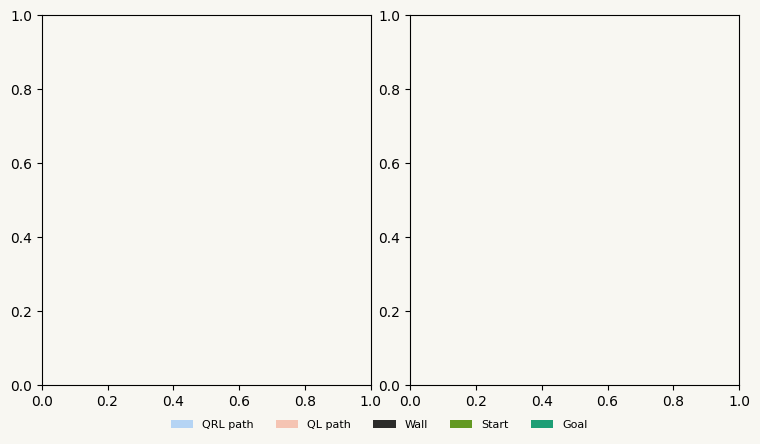

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.animation import FuncAnimation
from matplotlib.colors import ListedColormap

# ── Environment ────────────────────────────────────────────────────────────────
SIZE   = 5
START  = (0, 0)
GOAL   = (4, 4)
WALLS  = {1: [(0,2),(1,2),(3,2),(4,2)],
           2: [(0,2),(1,2),(2,2),(3,2)]}

def env_step(state, action, walls):
    x, y = state
    nx, ny = [(max(0,x-1),y),(min(SIZE-1,x+1),y),(x,max(0,y-1)),(x,min(SIZE-1,y+1))][action]
    if (nx,ny) in walls or (nx,ny)==state:
        return state, -1, False
    shaping = 0.3*(abs(x-GOAL[0])+abs(y-GOAL[1]) - abs(nx-GOAL[0])-abs(ny-GOAL[1]))
    done = (nx,ny)==GOAL
    return (nx,ny), (10 if done else shaping), done

# ── QRL Agent ─────────────────────────────────────────────────────────────────
def run_qrl(walls_list, episodes=60, max_steps=80, seed=42):
    rng = np.random.default_rng(seed)
    Q   = np.zeros((SIZE, SIZE, 4))
    A   = np.full((SIZE, SIZE, 4), 1/np.sqrt(4))
    Us  = 2*np.full((4,4),0.25) - np.eye(4)
    eps = 0.3
    paths = []
    for ep in range(episodes):
        walls = set(map(tuple, walls_list[ep]))
        state, path = START, [START]
        for _ in range(max_steps):
            x,y = state
            if rng.random() < eps:
                a = rng.integers(4)
            else:
                p = A[x,y]**2; s=p.sum()
                p = p/s if s>1e-9 else np.ones(4)/4
                a = rng.choice(4, p=p)
            ns, r, done = env_step(state, a, walls)
            nx,ny = ns
            Q[x,y,a] += 0.1*(r + 0.9*Q[nx,ny].max() - Q[x,y,a])
            if r < 0:
                A[x,y,a] *= 0.5
            else:
                qmax = np.abs(Q[x,y]).max()
                relq = Q[x,y,a]/qmax if qmax>1e-6 else 0
                L = min(3, int(round(0.5*max(0,relq)*3)))
                if L:
                    Ua = np.eye(4); Ua[a,a] = -1
                    Ug = Us @ Ua
                    for _ in range(L): A[x,y] = Ug @ A[x,y]
            norm = np.linalg.norm(A[x,y])
            A[x,y] = A[x,y]/norm if norm>1e-8 else np.full(4,1/np.sqrt(4))
            state = ns
            if ns != path[-1]: path.append(ns)
            if done: break
        eps = max(0.05, eps*0.995)
        paths.append({'path': path, 'reached': state==GOAL, 'steps': len(path)-1})
    return paths

# ── Classical QL ───────────────────────────────────────────────────────────────
def run_ql(walls_list, episodes=60, max_steps=80, seed=42):
    rng = np.random.default_rng(seed)
    Q   = np.zeros((SIZE, SIZE, 4))
    paths = []
    for ep in range(episodes):
        walls = set(map(tuple, walls_list[ep]))
        state, path = START, [START]
        for _ in range(max_steps):
            x,y = state
            if rng.random() < 0.2:
                a = rng.integers(4)
            else:
                a = int(np.random.choice(np.flatnonzero(Q[x,y]==Q[x,y].max())))
            ns, r, done = env_step(state, a, walls)
            nx,ny = ns
            Q[x,y,a] += 0.1*(r + 0.9*Q[nx,ny].max() - Q[x,y,a])
            state = ns
            if ns != path[-1]: path.append(ns)
            if done: break
        paths.append({'path': path, 'reached': state==GOAL, 'steps': len(path)-1})
    return paths

# ── Simulate ───────────────────────────────────────────────────────────────────
EPISODES  = 60
SHIFT_EP  = 30          # switch to phase 2 at episode 30
walls_seq = [WALLS[1 if ep < SHIFT_EP else 2] for ep in range(EPISODES)]

print("Simulating... ", end="", flush=True)
qrl_data = run_qrl(walls_seq)
ql_data  = run_ql(walls_seq)
print("done.")

# ── Drawing helpers ────────────────────────────────────────────────────────────
CELL   = 1.0
COLORS = dict(wall='#2C2C2A', start='#639922', goal='#1D9E75',
              empty='#F1EFE8', qrl_path='#B5D4F4', ql_path='#F5C4B3',
              qrl_agent='#185FA5', ql_agent='#993C1D')

def draw_grid(ax, ep_data, agent_color, path_color, walls, title):
    ax.clear()
    ax.set_aspect('equal'); ax.set_xlim(0,SIZE); ax.set_ylim(0,SIZE)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontsize=11, fontweight='bold', pad=6)

    visited = set(ep_data['path'])

    for r in range(SIZE):
        for c in range(SIZE):
            cell_rc = (r, c)
            if cell_rc in walls:           fc = COLORS['wall']
            elif cell_rc == GOAL:          fc = COLORS['goal']
            elif cell_rc == START:         fc = COLORS['start']
            elif cell_rc in visited:       fc = path_color
            else:                          fc = COLORS['empty']
            rect = plt.Rectangle((c, SIZE-1-r), CELL, CELL,
                                  fc=fc, ec='white', lw=0.8)
            ax.add_patch(rect)
            if cell_rc == START:
                ax.text(c+.5, SIZE-.5-r,'S',ha='center',va='center',
                        color='white',fontsize=10,fontweight='bold')
            if cell_rc == GOAL:
                ax.text(c+.5, SIZE-.5-r,'G',ha='center',va='center',
                        color='white',fontsize=10,fontweight='bold')

    path = ep_data['path']
    if len(path) > 1:
        xs = [p[1]+.5 for p in path]
        ys = [SIZE-.5-p[0] for p in path]
        ax.plot(xs, ys, color=agent_color, lw=2, zorder=3)
        ax.plot(xs[-1], ys[-1], 'o', color=agent_color,
                ms=10, zorder=4, mec='white', mew=1.5)

    status = "reached goal" if ep_data['reached'] else f"{ep_data['steps']} steps"
    ax.set_xlabel(status, fontsize=9, color='#444441')

# ── Figure & animation ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(9, 5))
fig.patch.set_facecolor('#F8F7F2')
for ax in axes: ax.set_facecolor('#F8F7F2')

ep_text = fig.text(0.5, 0.96, '', ha='center', va='top',
                   fontsize=12, fontweight='bold', color='#2C2C2A')
phase_text = fig.text(0.5, 0.91, '', ha='center', va='top',
                      fontsize=9, color='#5F5E5A')

legend_elems = [
    mpatches.Patch(fc=COLORS['qrl_path'],  label='QRL path'),
    mpatches.Patch(fc=COLORS['ql_path'],   label='QL path'),
    mpatches.Patch(fc=COLORS['wall'],      label='Wall'),
    mpatches.Patch(fc=COLORS['start'],     label='Start'),
    mpatches.Patch(fc=COLORS['goal'],      label='Goal'),
]
fig.legend(handles=legend_elems, loc='lower center', ncol=5,
           fontsize=8, frameon=False, bbox_to_anchor=(0.5, 0.01))

plt.subplots_adjust(top=0.86, bottom=0.12, wspace=0.12)

def animate(ep):
    walls = set(map(tuple, walls_seq[ep]))
    phase = 1 if ep < SHIFT_EP else 2
    ep_text.set_text(f"Episode {ep+1} / {EPISODES}")
    phase_text.set_text(f"Phase {phase}  —  {'middle gap open' if phase==1 else 'bottom gap open (wall dropped)'}")
    draw_grid(axes[0], qrl_data[ep], COLORS['qrl_agent'], COLORS['qrl_path'], walls, "QRL agent")
    draw_grid(axes[1], ql_data[ep],  COLORS['ql_agent'],  COLORS['ql_path'],  walls, "Classical Q-learning")
    return []

ani = FuncAnimation(fig, animate, frames=EPISODES, interval=350, blit=False, repeat=True)
plt.show()